In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

# Load feature set from Step 2
features = pd.read_csv('customer_features.csv')
print(f"Loaded: {features.shape}")
print(features[['customer_id','decline_rate','dispute_rate',
                 'late_night_ratio','avg_utilisation','RFM_score']].head(5))

Loaded: (37616, 24)
   customer_id  decline_rate  dispute_rate  late_night_ratio  avg_utilisation  \
0            1        0.0000           0.0            0.2632          0.09405   
1            2        0.0227           0.0            0.2727          0.10712   
2            3        0.0000           0.0            0.3571          0.14370   
3            5        0.2222           0.0            0.3333          0.18050   
4            6        0.0000           0.0            0.2667          0.12130   

   RFM_score  
0         10  
1         15  
2         11  
3          3  
4         11  


In [2]:
# Each rule contributes points to a 0-100 risk score
# Higher score = higher risk

df = features.copy()

# Thresholds based on distribution of your actual data
df['risk_pts_decline']    = np.where(df['decline_rate']    > 0.20, 30, 
                            np.where(df['decline_rate']    > 0.10, 15, 0))

df['risk_pts_dispute']    = np.where(df['dispute_rate']    > 0.10, 25,
                            np.where(df['dispute_rate']    > 0.05, 12, 0))

df['risk_pts_latenight']  = np.where(df['late_night_ratio'] > 0.30, 20,
                            np.where(df['late_night_ratio'] > 0.15, 10, 0))

df['risk_pts_utilisation']= np.where(df['avg_utilisation'] > 0.80, 15,
                            np.where(df['avg_utilisation'] > 0.60, 8,  0))

df['risk_pts_rfm']        = np.where(df['RFM_score'] <= 5, 10,
                            np.where(df['RFM_score'] <= 7,  5,  0))

# Total rule-based risk score (capped at 100)
df['rule_risk_score'] = (
    df['risk_pts_decline'] +
    df['risk_pts_dispute'] +
    df['risk_pts_latenight'] +
    df['risk_pts_utilisation'] +
    df['risk_pts_rfm']
).clip(0, 100)

print("Rule-based risk score distribution:")
print(df['rule_risk_score'].describe().round(2))
print(f"\nHigh risk customers (score > 50): {(df['rule_risk_score'] > 50).sum():,}")

Rule-based risk score distribution:
count    37616.00
mean        18.51
std         12.66
min          0.00
25%         10.00
50%         15.00
75%         25.00
max         85.00
Name: rule_risk_score, dtype: float64

High risk customers (score > 50): 891


In [3]:
# Features used for anomaly detection
iso_features = [
    'decline_rate', 'dispute_rate', 'late_night_ratio',
    'avg_utilisation', 'spend_velocity', 'avg_ticket_size',
    'merchant_diversity'
]

X = df[iso_features].fillna(0)

# Scale features to 0-1
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Isolation Forest — contamination=0.05 means ~5% flagged as anomalies
iso = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
df['anomaly_flag']  = iso.fit_predict(X_scaled)   # -1 = anomaly, 1 = normal
df['anomaly_score'] = iso.decision_function(X_scaled)  # lower = more anomalous

# Convert flag: 1 = anomaly, 0 = normal (easier to read)
df['anomaly_flag'] = (df['anomaly_flag'] == -1).astype(int)

print(f"Total customers flagged as anomalies: {df['anomaly_flag'].sum():,}")
print(f"Anomaly rate: {df['anomaly_flag'].mean()*100:.1f}%")

Total customers flagged as anomalies: 1,881
Anomaly rate: 5.0%


In [4]:
# Normalize anomaly score to 0-100 (invert so higher = riskier)
anomaly_norm = MinMaxScaler(feature_range=(0, 100))
df['anomaly_score_scaled'] = anomaly_norm.fit_transform(
    (-df['anomaly_score']).values.reshape(-1, 1)
)

# Final score = 60% rule-based + 40% anomaly model
df['final_risk_score'] = (
    0.60 * df['rule_risk_score'] +
    0.40 * df['anomaly_score_scaled']
).round(2)

# Risk tier labels
def risk_tier(score):
    if score >= 70: return 'High Risk'
    elif score >= 40: return 'Medium Risk'
    else: return 'Low Risk'

df['risk_tier'] = df['final_risk_score'].apply(risk_tier)

print("Risk tier distribution:")
print(df['risk_tier'].value_counts())
print(f"\nFinal risk score stats:")
print(df['final_risk_score'].describe().round(2))

Risk tier distribution:
risk_tier
Low Risk       35467
Medium Risk     2031
High Risk        118
Name: count, dtype: int64

Final risk score stats:
count    37616.00
mean        18.60
std         11.45
min          1.03
25%         10.48
50%         15.69
75%         23.21
max         91.00
Name: final_risk_score, dtype: float64


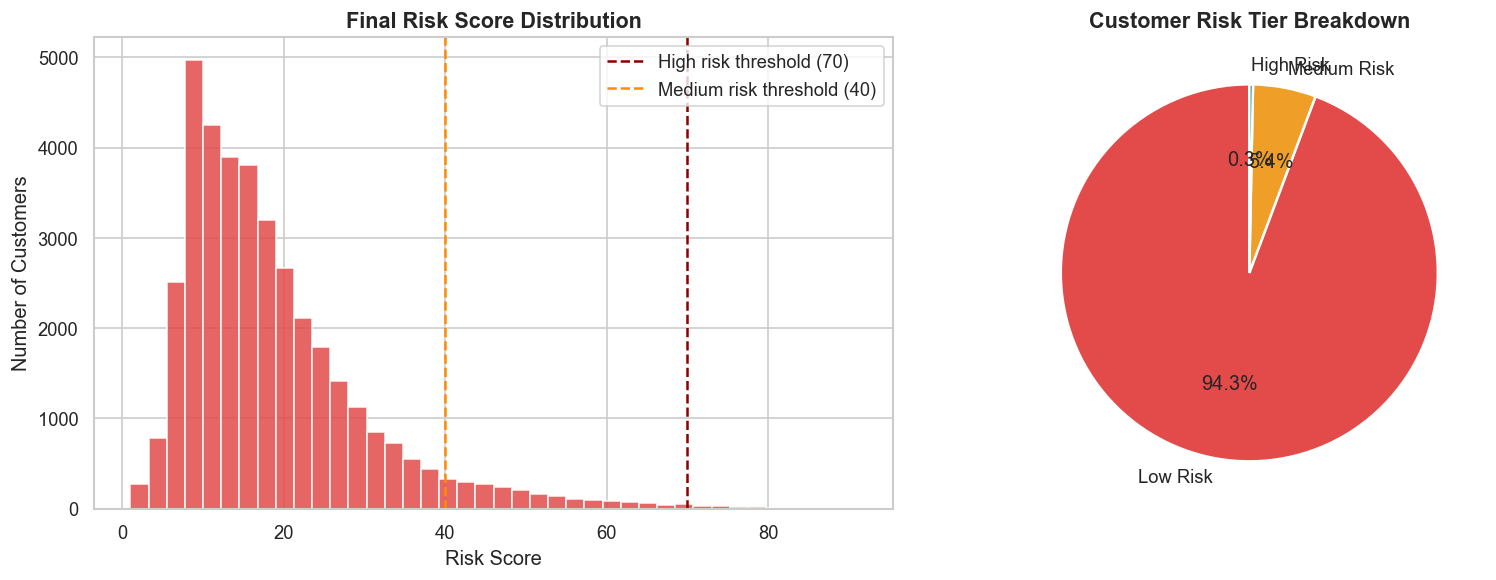

✓ risk_distribution.png saved


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Risk score histogram
axes[0].hist(df['final_risk_score'], bins=40, color='#E24B4A', edgecolor='white', alpha=0.85)
axes[0].axvline(70, color='darkred',   linestyle='--', linewidth=1.5, label='High risk threshold (70)')
axes[0].axvline(40, color='darkorange',linestyle='--', linewidth=1.5, label='Medium risk threshold (40)')
axes[0].set_title('Final Risk Score Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Risk Score')
axes[0].set_ylabel('Number of Customers')
axes[0].legend()

# Risk tier pie
tier_counts = df['risk_tier'].value_counts()
colors = ['#E24B4A', '#EF9F27', '#1D9E75']
axes[1].pie(tier_counts, labels=tier_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Customer Risk Tier Breakdown', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('risk_distribution.png', bbox_inches='tight')
plt.show()
print("✓ risk_distribution.png saved")

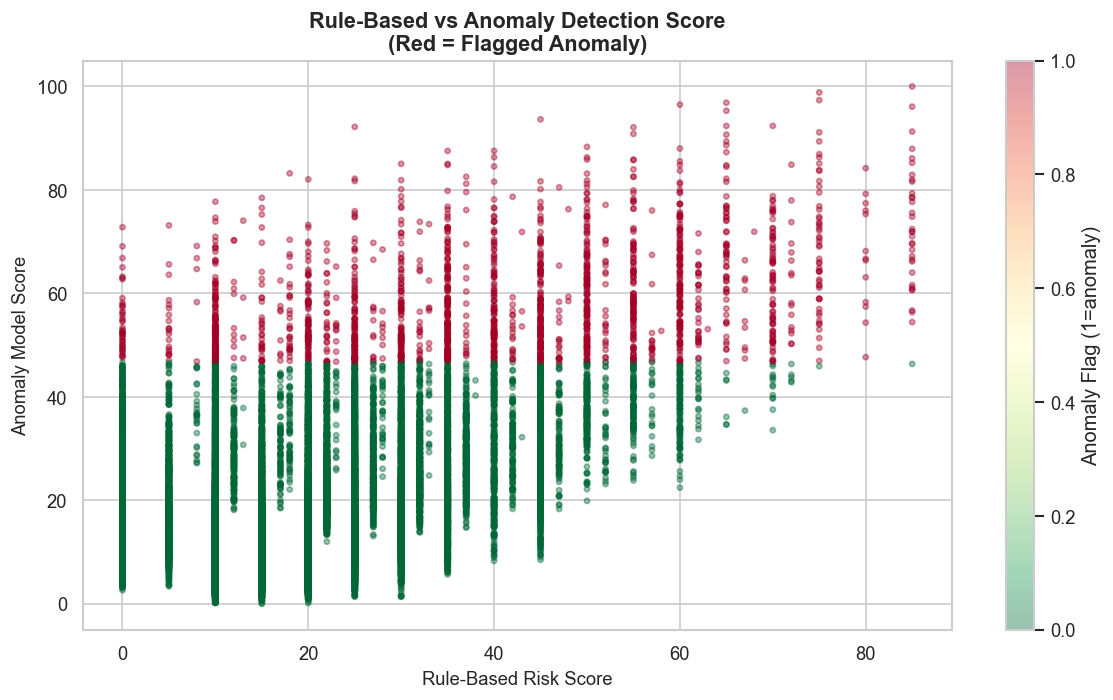

✓ anomaly_vs_rule.png saved


In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    df['rule_risk_score'],
    df['anomaly_score_scaled'],
    c=df['anomaly_flag'],
    cmap='RdYlGn_r',
    alpha=0.4,
    s=10
)

ax.set_xlabel('Rule-Based Risk Score', fontsize=11)
ax.set_ylabel('Anomaly Model Score', fontsize=11)
ax.set_title('Rule-Based vs Anomaly Detection Score\n(Red = Flagged Anomaly)', 
             fontsize=13, fontweight='bold')

plt.colorbar(scatter, label='Anomaly Flag (1=anomaly)')
plt.tight_layout()
plt.savefig('anomaly_vs_rule.png', bbox_inches='tight')
plt.show()
print("✓ anomaly_vs_rule.png saved")

In [7]:
# Keep only the columns needed for Power BI and Step 4
risk_output = df[[
    'customer_id', 'income_band', 'city', 'age',
    'total_spend', 'avg_ticket_size', 'txn_count',
    'decline_rate', 'dispute_rate', 'late_night_ratio',
    'avg_utilisation', 'spend_velocity', 'merchant_diversity',
    'RFM_score', 'rfm_segment',
    'rule_risk_score', 'anomaly_flag', 'final_risk_score', 'risk_tier'
]].copy()

risk_output.to_csv('customer_risk_scores.csv', index=False)
print(f"✓ customer_risk_scores.csv saved")
print(f"Shape: {risk_output.shape}")
print(f"\nSample high-risk customers:")
print(risk_output[risk_output['risk_tier'] == 'High Risk']
      .sort_values('final_risk_score', ascending=False)
      .head(5)[['customer_id','decline_rate','dispute_rate',
                 'final_risk_score','risk_tier']])

✓ customer_risk_scores.csv saved
Shape: (37616, 19)

Sample high-risk customers:
       customer_id  decline_rate  dispute_rate  final_risk_score  risk_tier
8177         10876        0.5714        0.2857             91.00  High Risk
33419        44444        0.2857        0.2857             89.44  High Risk
29084        38702        0.4000        0.2000             87.51  High Risk
31413        41786        0.4000        0.2000             86.17  High Risk
15810        21064        0.4286        0.1429             85.44  High Risk
